In [1]:
import json
from collections import Counter

def analyze_label_studio_data(json_file_path):
    # Загружаем данные из JSON файла
    with open(json_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # Инициализируем счетчики
    total_images = 0
    total_annotations = 0
    class_counter = Counter()
    
    # Проходим по всем задачам (изображениям)
    for task in data:
        # Проверяем, есть ли аннотации
        if 'annotations' in task and task['annotations']:
            total_images += 1
            
            # Берем первую аннотацию (обычно она основная)
            annotation = task['annotations'][0]
            
            # Проверяем, есть ли результат разметки
            if 'result' in annotation:
                results = annotation['result']
                
                # Считаем все объекты на изображении
                for result in results:
                    if 'value' in result and 'rectanglelabels' in result['value']:
                        labels = result['value']['rectanglelabels']
                        if labels:  # Проверяем, что метка не пустая
                            class_name = labels[0]  # Берем первую метку (обычно она одна)
                            class_counter[class_name] += 1
                            total_annotations += 1
    
    # Выводим результаты
    print("=" * 50)
    print("СТАТИСТИКА РАЗМЕТКИ ДАННЫХ")
    print("=" * 50)
    print(f"Всего изображений: {total_images}")
    print(f"Всего размеченных объектов: {total_annotations}")
    print(f"Среднее количество объектов на изображение: {total_annotations/total_images:.2f}")
    print("\n" + "=" * 50)
    print("РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ:")
    print("=" * 50)
    
    # Сортируем классы по убыванию количества
    sorted_classes = sorted(class_counter.items(), key=lambda x: x[1], reverse=True)
    
    for class_name, count in sorted_classes:
        percentage = (count / total_annotations) * 100
        print(f"{class_name}: {count} объектов ({percentage:.1f}%)")
    
    print("\n" + "=" * 50)
    print("ИСПОЛЬЗУЕМЫЕ КЛАССЫ (всего {}):".format(len(class_counter)))
    print("=" * 50)
    for class_name in sorted(class_counter.keys()):
        print(f"- {class_name}")
    
    # Дополнительная статистика
    print("\n" + "=" * 50)
    print("ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:")
    print("=" * 50)
    print(f"Наиболее частый класс: {sorted_classes[0][0]} ({sorted_classes[0][1]} объектов)")
    print(f"Наименее частый класс: {sorted_classes[-1][0]} ({sorted_classes[-1][1]} объектов)")
    
    # Проверяем баланс классов
    max_count = max(class_counter.values())
    min_count = min(class_counter.values())
    balance_ratio = min_count / max_count if max_count > 0 else 0
    
    print(f"\nБаланс классов (min/max): {balance_ratio:.3f}")
    if balance_ratio >= 0.2:
        print("Статус: Относительно сбалансированный датасет")
    elif balance_ratio > 0.05:
        print("Статус: Умеренный дисбаланс")
    else:
        print("Статус: Сильный дисбаланс классов")
    
    return {
        'total_images': total_images,
        'total_annotations': total_annotations,
        'class_distribution': dict(class_counter),
        'average_per_image': total_annotations/total_images if total_images > 0 else 0
    }

# Основная часть скрипта
if __name__ == "__main__":
    # Укажите путь к вашему JSON файлу
    json_file = "datection.json"
    
    try:
        stats = analyze_label_studio_data(json_file)
        
        # Сохраняем результаты в файл для дальнейшего использования
        with open("annotation_statistics.json", "w", encoding='utf-8') as f:
            json.dump(stats, f, ensure_ascii=False, indent=2)
        print("\nРезультаты сохранены в файл: annotation_statistics.json")
        
    except FileNotFoundError:
        print(f"Ошибка: Файл '{json_file}' не найден!")
        print("Убедитесь, что файл находится в той же папке, что и скрипт.")
    except json.JSONDecodeError:
        print(f"Ошибка: Файл '{json_file}' содержит некорректный JSON!")
    except Exception as e:
        print(f"Произошла ошибка: {str(e)}")

СТАТИСТИКА РАЗМЕТКИ ДАННЫХ
Всего изображений: 114
Всего размеченных объектов: 476
Среднее количество объектов на изображение: 4.18

РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ:
Легковой автомобиль: 132 объектов (27.7%)
Мотоцикл: 77 объектов (16.2%)
Внедорожник: 63 объектов (13.2%)
Грузовик: 60 объектов (12.6%)
Рабочая техника: 57 объектов (12.0%)
Автобус: 50 объектов (10.5%)
Фургон: 37 объектов (7.8%)

ИСПОЛЬЗУЕМЫЕ КЛАССЫ (всего 7):
- Автобус
- Внедорожник
- Грузовик
- Легковой автомобиль
- Мотоцикл
- Рабочая техника
- Фургон

ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:
Наиболее частый класс: Легковой автомобиль (132 объектов)
Наименее частый класс: Фургон (37 объектов)

Баланс классов (min/max): 0.280
Статус: Относительно сбалансированный датасет

Результаты сохранены в файл: annotation_statistics.json


In [6]:
import json
from collections import Counter

def analyze_label_studio_detailed(json_file_path):
    """Более детальный анализ данных разметки"""
    
    with open(json_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    total_images = 0
    total_annotations = 0
    class_counter = Counter()
    annotations_per_image = []
    
    for task in data:
        if 'annotations' in task and task['annotations']:
            annotation = task['annotations'][0]
            
            if 'result' in annotation:
                results = annotation['result']
                image_annotations = 0
                
                for result in results:
                    if 'value' in result and 'rectanglelabels' in result['value']:
                        labels = result['value']['rectanglelabels']
                        if labels:
                            class_name = labels[0]
                            class_counter[class_name] += 1
                            image_annotations += 1
                
                if image_annotations > 0:
                    total_images += 1
                    total_annotations += image_annotations
                    annotations_per_image.append(image_annotations)
    
    # Основная статистика
    print("=" * 60)
    print("ДЕТАЛЬНАЯ СТАТИСТИКА РАЗМЕТКИ")
    print("=" * 60)
    print(f"Всего изображений: {total_images}")
    print(f"Всего размеченных объектов: {total_annotations}")
    
    if annotations_per_image:
        avg_annotations = sum(annotations_per_image) / len(annotations_per_image)
        max_annotations = max(annotations_per_image)
        min_annotations = min(annotations_per_image)
        
        print(f"Объектов на изображение (в среднем): {avg_annotations:.2f}")
        print(f"Максимум объектов на изображении: {max_annotations}")
        print(f"Минимум объектов на изображении: {min_annotations}")
    
    print("\n" + "=" * 60)
    print("РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ (отсортировано):")
    print("=" * 60)
    
    sorted_classes = sorted(class_counter.items(), key=lambda x: x[1], reverse=True)
    
    for idx, (class_name, count) in enumerate(sorted_classes, 1):
        percentage = (count / total_annotations) * 100
        bar = "█" * int(percentage / 2)  # Визуализация в виде полоски
        print(f"{idx:2}. {class_name:20} {count:5} ({percentage:5.1f}%) {bar}")
    
    # Создаем словарь с результатами
    result = {
        'total_images': total_images,
        'total_annotations': total_annotations,
        'class_distribution': dict(class_counter),
        'annotations_per_image_stats': {
            'average': avg_annotations,
            'max': max_annotations,
            'min': min_annotations
        } if annotations_per_image else {}
    }
    
    return result

# Использование
if __name__ == "__main__":
    json_file = "project-2-at-2026-01-16-11-25-94f62647.json"
    
    try:
        stats = analyze_label_studio_detailed(json_file)
        
        # Сохраняем в JSON
        with open("detailed_annotation_stats.json", "w", encoding='utf-8') as f:
            json.dump(stats, f, ensure_ascii=False, indent=2)
            
        print(f"\nСтатистика сохранена в 'detailed_annotation_stats.json'")
        
    except Exception as e:
        print(f"Ошибка: {e}")

ДЕТАЛЬНАЯ СТАТИСТИКА РАЗМЕТКИ
Всего изображений: 118
Всего размеченных объектов: 700
Объектов на изображение (в среднем): 5.93
Максимум объектов на изображении: 78
Минимум объектов на изображении: 1

РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ (отсортировано):
 1. Легковой автомобиль    255 ( 36.4%) ██████████████████
 2. Внедорожник            105 ( 15.0%) ███████
 3. Мотоцикл                94 ( 13.4%) ██████
 4. Грузовик                74 ( 10.6%) █████
 5. Рабочая техника         68 (  9.7%) ████
 6. Фургон                  53 (  7.6%) ███
 7. Автобус                 51 (  7.3%) ███

Статистика сохранена в 'detailed_annotation_stats.json'


СТАТИСТИКА РАЗМЕТКИ ДАННЫХ
Всего изображений: 114
Всего размеченных объектов: 476
Среднее количество объектов на изображение: 4.18

РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ:
Легковой автомобиль: 132 объектов (27.7%)
Мотоцикл: 77 объектов (16.2%)
Внедорожник: 63 объектов (13.2%)
Грузовик: 60 объектов (12.6%)
Рабочая техника: 57 объектов (12.0%)
Автобус: 50 объектов (10.5%)
Фургон: 37 объектов (7.8%)

ИСПОЛЬЗУЕМЫЕ КЛАССЫ (всего 7):
- Автобус
- Внедорожник
- Грузовик
- Легковой автомобиль
- Мотоцикл
- Рабочая техника
- Фургон

ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:
Наиболее частый класс: Легковой автомобиль (132 объектов)
Наименее частый класс: Фургон (37 объектов)

Баланс классов (min/max): 0.280
Статус: Относительно сбалансированный датасет

СОЗДАНИЕ ВИЗУАЛИЗАЦИЙ...


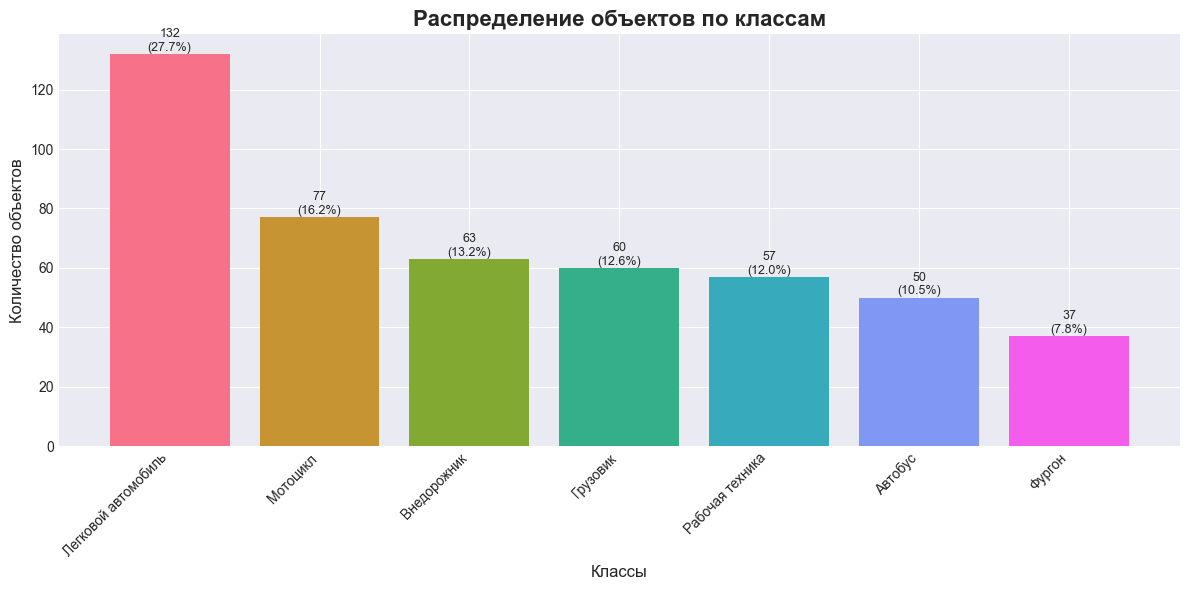

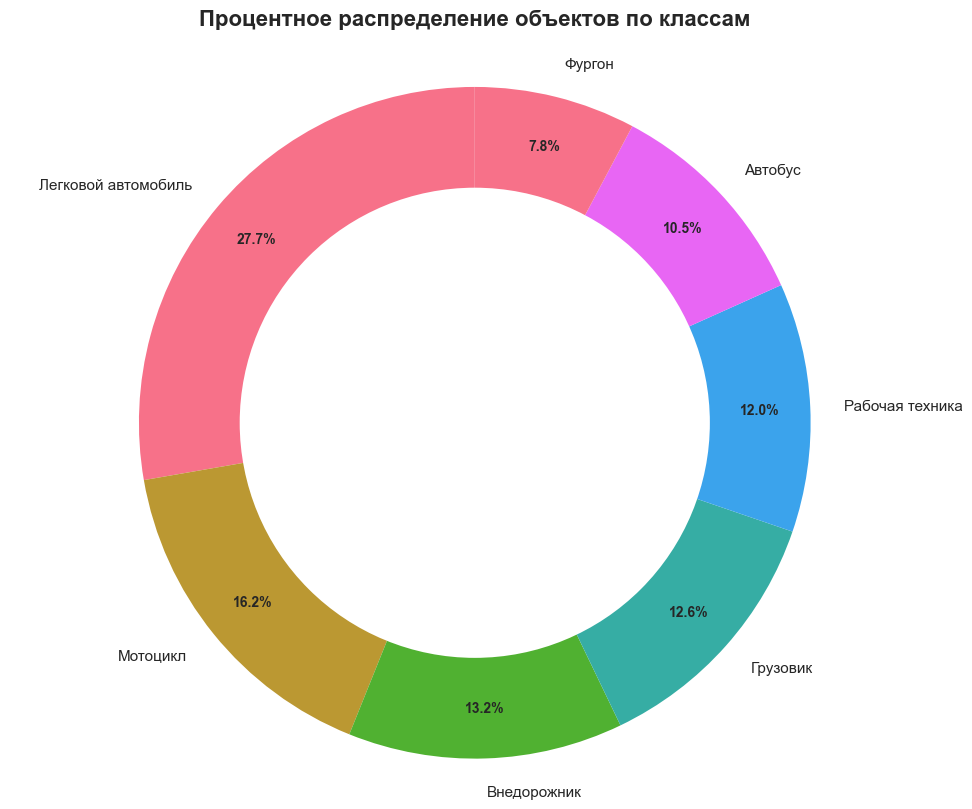

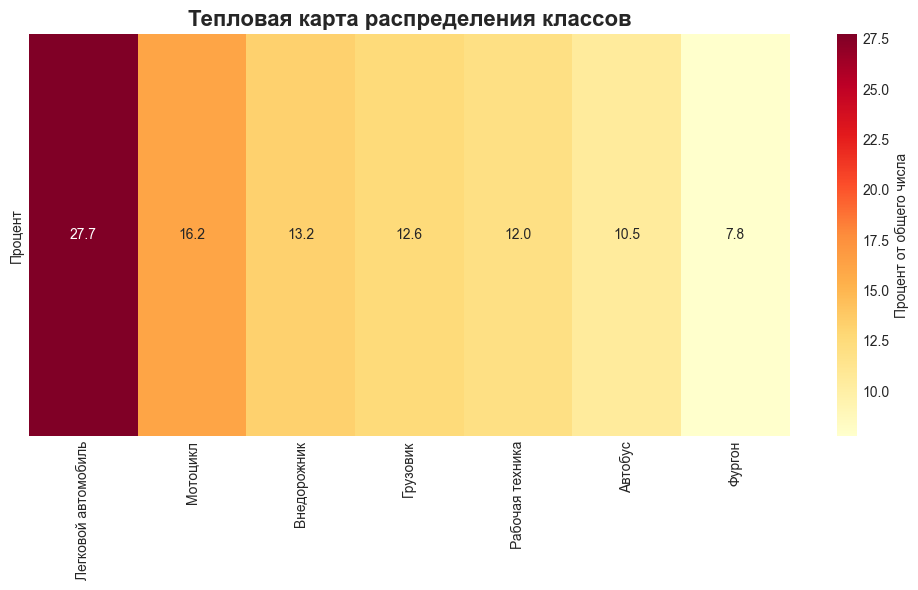

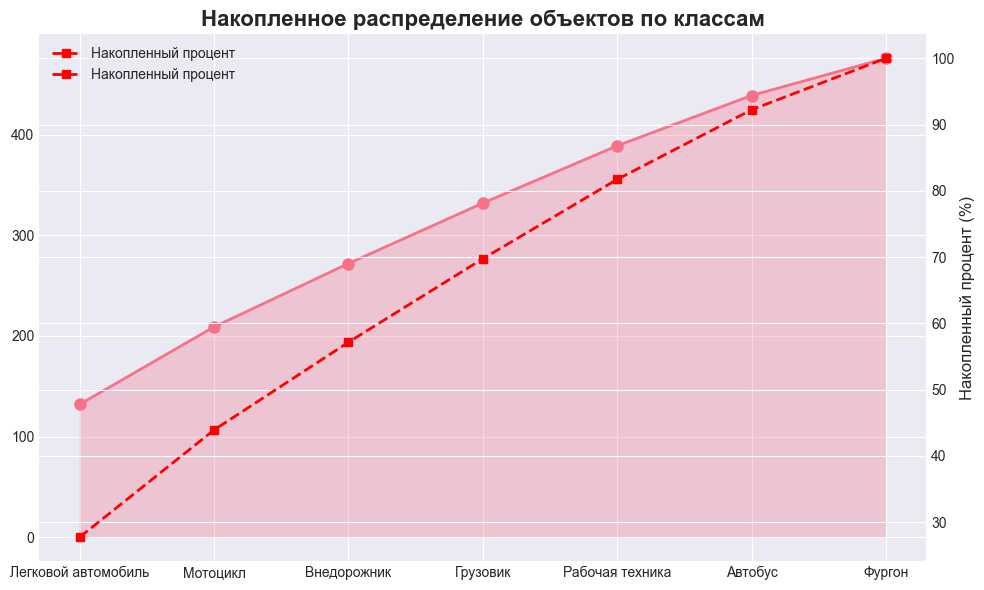

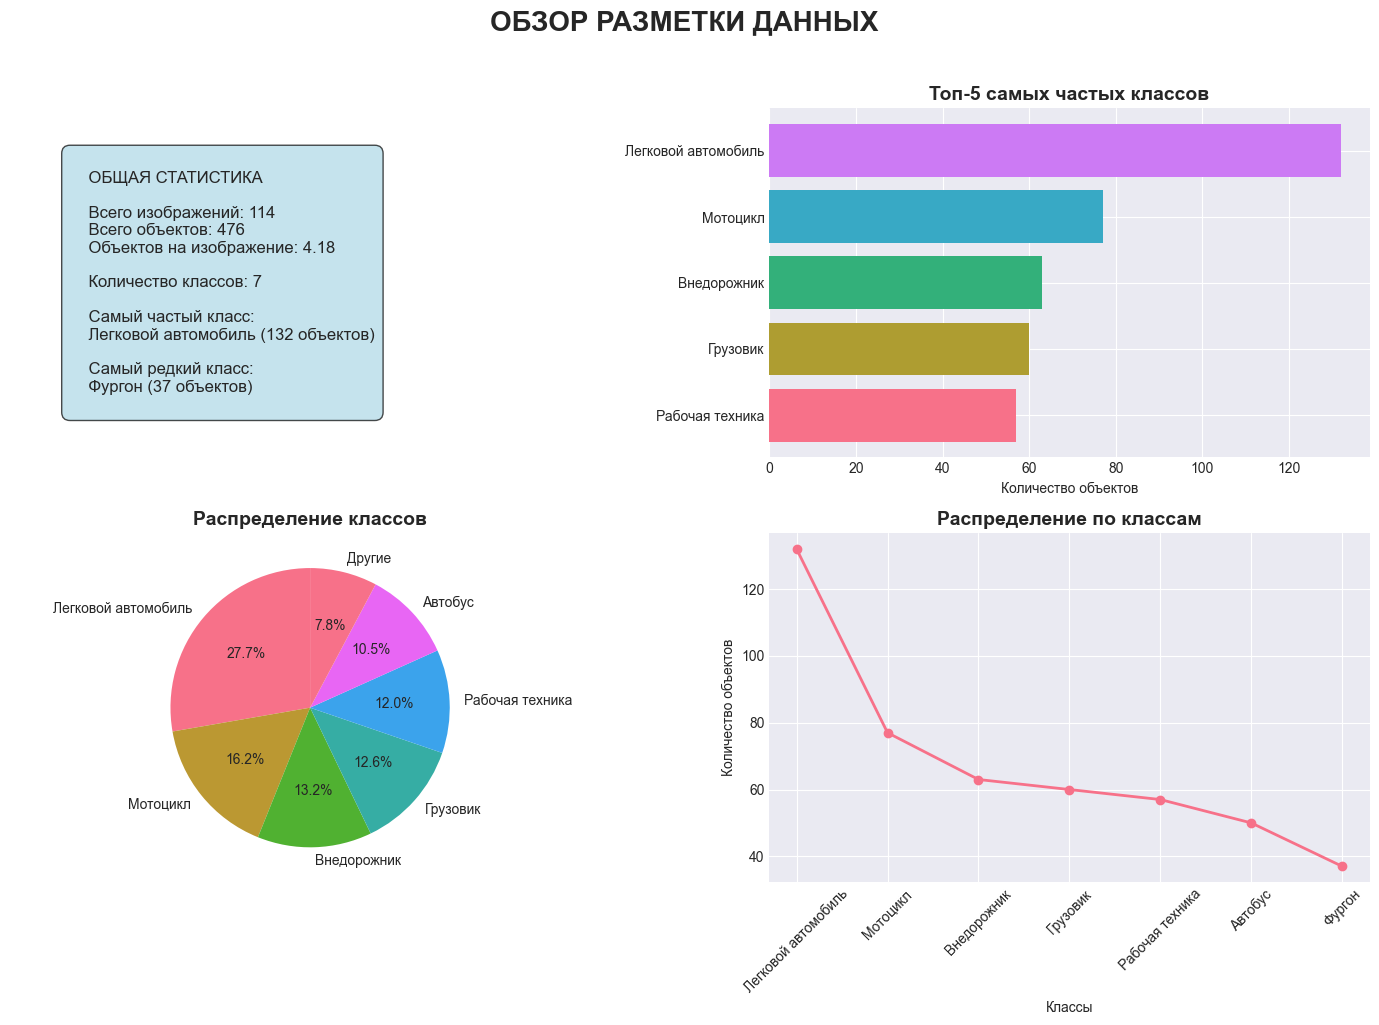


Все диаграммы сохранены в папке: 'visualizations/'

Результаты сохранены в файл: annotation_statistics.json


In [3]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
import os

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

def create_visualizations(class_counter, total_images, total_annotations, output_dir="visualizations"):
    """
    Создает визуализации на основе статистики разметки
    """
    # Создаем директорию для сохранения графиков
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Подготовка данных
    sorted_classes = sorted(class_counter.items(), key=lambda x: x[1], reverse=True)
    class_names = [item[0] for item in sorted_classes]
    class_counts = [item[1] for item in sorted_classes]
    percentages = [(count / total_annotations) * 100 for count in class_counts]
    
    # 1. Столбчатая диаграмма распределения классов
    plt.figure(figsize=(12, 6))
    bars = plt.bar(class_names, class_counts, color=sns.color_palette("husl", len(class_names)))
    
    # Добавляем значения над столбцами
    for bar, count, percentage in zip(bars, class_counts, percentages):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{count}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=9)
    
    plt.title('Распределение объектов по классам', fontsize=16, fontweight='bold')
    plt.xlabel('Классы', fontsize=12)
    plt.ylabel('Количество объектов', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'class_distribution_bar.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2. Круговая диаграмма распределения классов
    plt.figure(figsize=(10, 8))
    
    # Создаем круговую диаграмму с выносками
    wedges, texts, autotexts = plt.pie(class_counts, labels=class_names, autopct='%1.1f%%',
                                       startangle=90, pctdistance=0.85)
    
    # Настраиваем внешний вид
    plt.setp(autotexts, size=10, weight="bold")
    plt.setp(texts, size=11)
    
    # Добавляем круг в центре для donut chart
    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)
    
    plt.title('Процентное распределение объектов по классам', fontsize=16, fontweight='bold', y=1.05)
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'class_distribution_pie.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # 3. Heatmap с процентным соотношением (для визуализации баланса)
    plt.figure(figsize=(10, 6))
    
    # Создаем матрицу для heatmap (одномерную, но в виде матрицы)
    heatmap_data = np.array(percentages).reshape(1, -1)
    
    sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
                xticklabels=class_names, yticklabels=['Процент'],
                cbar_kws={'label': 'Процент от общего числа'})
    
    plt.title('Тепловая карта распределения классов', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'class_distribution_heatmap.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # 4. Box plot для визуализации распределения (если бы было больше данных)
    # Вместо этого создадим график накопленного распределения
    plt.figure(figsize=(10, 6))
    
    # Накопленная сумма
    cumulative_counts = np.cumsum(class_counts)
    cumulative_percentages = np.cumsum(percentages)
    
    plt.plot(class_names, cumulative_counts, 'o-', linewidth=2, markersize=8, label='Накопленное количество')
    plt.fill_between(class_names, 0, cumulative_counts, alpha=0.3)
    
    # Вторая ось Y для процентов
    ax2 = plt.gca().twinx()
    ax2.plot(class_names, cumulative_percentages, 's--', color='red', linewidth=2, markersize=6, label='Накопленный процент')
    
    plt.title('Накопленное распределение объектов по классам', fontsize=16, fontweight='bold')
    plt.xlabel('Классы', fontsize=12)
    plt.gca().set_ylabel('Накопленное количество', fontsize=12)
    ax2.set_ylabel('Накопленный процент (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # Объединяем легенды
    lines1, labels1 = plt.gca().get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    plt.gca().legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'cumulative_distribution.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # 5. Общая информационная панель
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('ОБЗОР РАЗМЕТКИ ДАННЫХ', fontsize=20, fontweight='bold', y=1.02)
    
    # Подграфик 1: Основная статистика (текст)
    axes[0, 0].axis('off')
    stats_text = f"""
    ОБЩАЯ СТАТИСТИКА
    
    Всего изображений: {total_images}
    Всего объектов: {total_annotations}
    Объектов на изображение: {total_annotations/total_images:.2f}
    
    Количество классов: {len(class_names)}
    
    Самый частый класс:
    {class_names[0]} ({class_counts[0]} объектов)
    
    Самый редкий класс:
    {class_names[-1]} ({class_counts[-1]} объектов)
    """
    axes[0, 0].text(0.1, 0.5, stats_text, fontsize=12, va='center',
                   bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.7))
    
    # Подграфик 2: Столбчатая диаграмма (топ-5 классов)
    top_n = min(5, len(class_names))
    axes[0, 1].barh(class_names[:top_n][::-1], class_counts[:top_n][::-1], color=sns.color_palette("husl", top_n))
    axes[0, 1].set_title(f'Топ-{top_n} самых частых классов', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Количество объектов')
    
    # Подграфик 3: Круговая диаграмма (топ-6 классов, остальные - "другие")
    if len(class_names) > 6:
        top_6_counts = class_counts[:6]
        other_count = sum(class_counts[6:])
        pie_labels = class_names[:6] + ['Другие']
        pie_sizes = list(top_6_counts) + [other_count]
    else:
        pie_labels = class_names
        pie_sizes = class_counts
    
    axes[1, 0].pie(pie_sizes, labels=pie_labels, autopct='%1.1f%%', startangle=90)
    axes[1, 0].set_title('Распределение классов', fontsize=14, fontweight='bold')
    
    # Подграфик 4: Линейный график распределения
    axes[1, 1].plot(class_names, class_counts, 'o-', linewidth=2, markersize=6)
    axes[1, 1].set_title('Распределение по классам', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Классы')
    axes[1, 1].set_ylabel('Количество объектов')
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'dashboard_overview.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nВсе диаграммы сохранены в папке: '{output_dir}/'")

def analyze_label_studio_data(json_file_path, create_plots=True):
    """
    Анализирует данные из Label Studio и создает визуализации
    """
    # Загружаем данные из JSON файла
    with open(json_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # Инициализируем счетчики
    total_images = 0
    total_annotations = 0
    class_counter = Counter()
    
    # Проходим по всем задачам (изображениям)
    for task in data:
        # Проверяем, есть ли аннотации
        if 'annotations' in task and task['annotations']:
            total_images += 1
            
            # Берем первую аннотацию (обычно она основная)
            annotation = task['annotations'][0]
            
            # Проверяем, есть ли результат разметки
            if 'result' in annotation:
                results = annotation['result']
                
                # Считаем все объекты на изображении
                for result in results:
                    if 'value' in result and 'rectanglelabels' in result['value']:
                        labels = result['value']['rectanglelabels']
                        if labels:  # Проверяем, что метка не пустая
                            class_name = labels[0]  # Берем первую метку (обычно она одна)
                            class_counter[class_name] += 1
                            total_annotations += 1
    
    # Выводим результаты в консоль
    print("=" * 50)
    print("СТАТИСТИКА РАЗМЕТКИ ДАННЫХ")
    print("=" * 50)
    print(f"Всего изображений: {total_images}")
    print(f"Всего размеченных объектов: {total_annotations}")
    print(f"Среднее количество объектов на изображение: {total_annotations/total_images:.2f}")
    print("\n" + "=" * 50)
    print("РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ:")
    print("=" * 50)
    
    # Сортируем классы по убыванию количества
    sorted_classes = sorted(class_counter.items(), key=lambda x: x[1], reverse=True)
    
    for class_name, count in sorted_classes:
        percentage = (count / total_annotations) * 100
        print(f"{class_name}: {count} объектов ({percentage:.1f}%)")
    
    print("\n" + "=" * 50)
    print("ИСПОЛЬЗУЕМЫЕ КЛАССЫ (всего {}):".format(len(class_counter)))
    print("=" * 50)
    for class_name in sorted(class_counter.keys()):
        print(f"- {class_name}")
    
    # Дополнительная статистика
    print("\n" + "=" * 50)
    print("ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:")
    print("=" * 50)
    print(f"Наиболее частый класс: {sorted_classes[0][0]} ({sorted_classes[0][1]} объектов)")
    print(f"Наименее частый класс: {sorted_classes[-1][0]} ({sorted_classes[-1][1]} объектов)")
    
    # Проверяем баланс классов
    max_count = max(class_counter.values())
    min_count = min(class_counter.values())
    balance_ratio = min_count / max_count if max_count > 0 else 0
    
    print(f"\nБаланс классов (min/max): {balance_ratio:.3f}")
    if balance_ratio >= 0.2:
        print("Статус: Относительно сбалансированный датасет")
    elif balance_ratio > 0.05:
        print("Статус: Умеренный дисбаланс")
    else:
        print("Статус: Сильный дисбаланс классов")
    
    # Создаем визуализации
    if create_plots and total_annotations > 0:
        print("\n" + "=" * 50)
        print("СОЗДАНИЕ ВИЗУАЛИЗАЦИЙ...")
        print("=" * 50)
        create_visualizations(class_counter, total_images, total_annotations)
    
    return {
        'total_images': total_images,
        'total_annotations': total_annotations,
        'class_distribution': dict(class_counter),
        'average_per_image': total_annotations/total_images if total_images > 0 else 0,
        'balance_ratio': balance_ratio
    }

# Основная часть скрипта
if __name__ == "__main__":
    # Укажите путь к вашему JSON файлу
    json_file = "datection.json"
    
    try:
        # Проверяем наличие необходимых библиотек
        try:
            import matplotlib
            import seaborn
            create_plots = True
        except ImportError:
            print("ВНИМАНИЕ: Библиотеки для визуализации не установлены.")
            print("Установите их командой: pip install matplotlib seaborn")
            print("Продолжаю без создания диаграмм...")
            create_plots = False
        
        stats = analyze_label_studio_data(json_file, create_plots=create_plots)
        
        # Сохраняем результаты в файл для дальнейшего использования
        with open("annotation_statistics.json", "w", encoding='utf-8') as f:
            json.dump(stats, f, ensure_ascii=False, indent=2)
        print("\nРезультаты сохранены в файл: annotation_statistics.json")
        
    except FileNotFoundError:
        print(f"Ошибка: Файл '{json_file}' не найден!")
        print("Убедитесь, что файл находится в той же папке, что и скрипт.")
    except json.JSONDecodeError:
        print(f"Ошибка: Файл '{json_file}' содержит некорректный JSON!")
    except Exception as e:
        print(f"Произошла ошибка: {str(e)}")